In [30]:
import folium
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [17]:
df = pd.read_csv('aisdk-2025-05-16.csv')
print(df.head())

KeyboardInterrupt: 

In [ ]:
df2 = pd.read_csv('aisdk-2025-05-17.csv')

In [21]:
df2.columns

Index(['# Timestamp', 'Type of mobile', 'MMSI', 'Latitude', 'Longitude',
       'Navigational status', 'ROT', 'SOG', 'COG', 'Heading', 'IMO',
       'Callsign', 'Name', 'Ship type', 'Cargo type', 'Width', 'Length',
       'Type of position fixing device', 'Draught', 'Destination', 'ETA',
       'Data source type', 'A', 'B', 'C', 'D'],
      dtype='object')

In [22]:
laivas=df2[df2['MMSI'] ==  311014800] 
print(laivas)


                  # Timestamp Type of mobile       MMSI   Latitude  Longitude  \
8032489   17/05/2025 07:48:40        Class A  311014800  53.634955   6.181355   
8076933   17/05/2025 07:51:38        Class A  311014800  53.634937   6.181280   
8127949   17/05/2025 07:55:06        Class A  311014800  53.634937   6.181280   
8165488   17/05/2025 07:57:40        Class A  311014800  53.634940   6.181323   
8209107   17/05/2025 08:00:39        Class A  311014800  53.634988   6.181338   
8215567   17/05/2025 08:01:05        Class A  311014800  53.634988   6.181338   
8254421   17/05/2025 08:03:41        Class A  311014800  53.634978   6.181420   
8298206   17/05/2025 08:06:41        Class A  311014800  53.634992   6.181463   
8304193   17/05/2025 08:07:05        Class A  311014800  53.634992   6.181463   
8341948   17/05/2025 08:09:41        Class A  311014800  53.635028   6.181458   
8341958   17/05/2025 08:09:41        Class A  311014800  53.635028   6.181458   
8386246   17/05/2025 08:12:4

In [35]:
print(laivas['Latitude'])

8032489     53.634955
8076933     53.634937
8127949     53.634937
8165488     53.634940
8209107     53.634988
8215567     53.634988
8254421     53.634978
8298206     53.634992
8304193     53.634992
8341948     53.635028
8341958     53.635028
8386246     53.635055
8392201     53.635055
8392216     53.635055
8430610     53.635083
8476866     53.635072
8567272     53.635102
8573036     53.635102
8612363     53.635150
9433771     53.635332
9612685     53.635325
9701252     53.635382
15337009    53.634900
Name: Latitude, dtype: float64


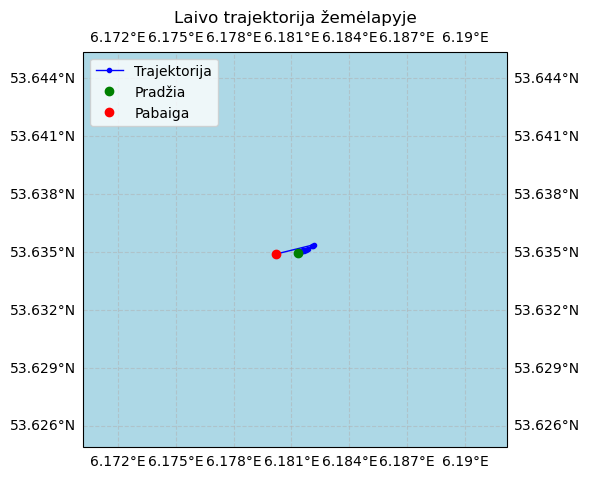

In [36]:
laivas_ = laivas.sort_values("# Timestamp")  

laivas_ = laivas_.sort_values("# Timestamp")

lats = laivas_["Latitude"].values
lons = laivas_["Longitude"].values

# Paimam mažą langą aplink trajektoriją
lat_min, lat_max = lats.min() - 0.01, lats.max() + 0.01
lon_min, lon_max = lons.min() - 0.01, lons.max() + 0.01

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(6, 8))
ax = plt.axes(projection=proj)

# Fokusas į tavo zoną
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)

# Foniniai elementai
ax.coastlines(resolution="10m")
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)

# Trajektorija
ax.plot(
    lons, lats,
    "-o",
    color="blue",
    markersize=3,
    linewidth=1,
    transform=proj,
    label="Trajektorija",
)

# Pradžia / pabaiga
ax.plot(lons[0], lats[0], "o", color="green", markersize=6,
        transform=proj, label="Pradžia")
ax.plot(lons[-1], lats[-1], "o", color="red", markersize=6,
        transform=proj, label="Pabaiga")

ax.set_title("Laivo trajektorija žemėlapyje")
ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig("laivo_trajektorija_map.png", dpi=300)
plt.show()

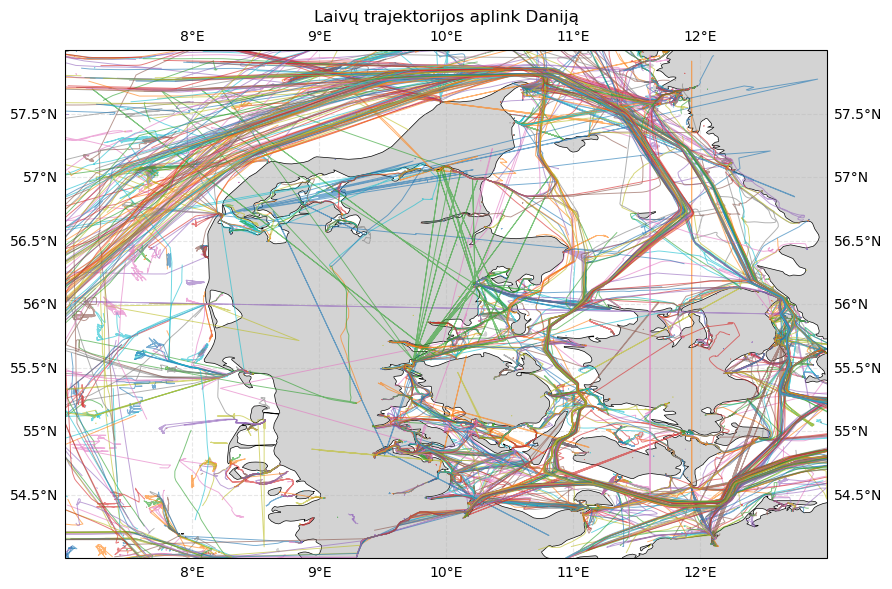

In [34]:
lat_min, lat_max = 54.0, 58.0
lon_min, lon_max = 7.0, 13.0

mask = (
    (df2["Latitude"]  >= lat_min) &
    (df2["Latitude"]  <= lat_max) &
    (df2["Longitude"] >= lon_min) &
    (df2["Longitude"] <= lon_max)
)

df_dk = df2[mask].copy()
f_dk = df_dk.sort_values("# Timestamp")

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=proj)

# Fokusas į Danijos bbox
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)

# Foninis žemėlapis
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="white")
ax.coastlines(resolution="10m", linewidth=0.5)
ax.gridlines(draw_labels=True, linestyle="--", alpha=0.3)

# Kiekvienam laivui – atskira linija
for mmsi, g in df_dk.groupby("MMSI"):
    ax.plot(
        g["Longitude"].values,
        g["Latitude"].values,
        linewidth=0.7,
        alpha=0.6,
        transform=proj,
    )

ax.set_title("Laivų trajektorijos aplink Daniją")
plt.tight_layout()
plt.show()


/opt/anaconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Trajektorijų segmentų skaičius: 4998


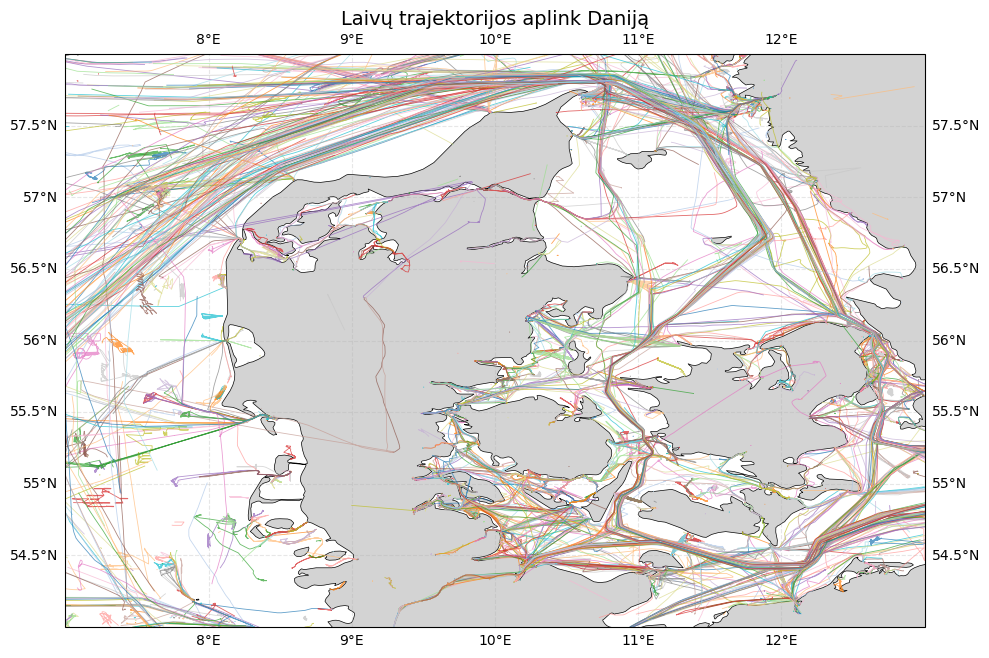

In [38]:
df2["# Timestamp"] = pd.to_datetime(df2["# Timestamp"])

# === 2. Filtras aplink Daniją (bbox – pasireguliuok ribas jei reikia) ===

lat_min, lat_max = 54.0, 58.0
lon_min, lon_max = 7.0, 13.0

mask = (
    (df2["Latitude"]  >= lat_min) &
    (df2["Latitude"]  <= lat_max) &
    (df2["Longitude"] >= lon_min) &
    (df2["Longitude"] <= lon_max)
)

df_dk = df2[mask].copy()
df_dk = df_dk.dropna(subset=["Latitude", "Longitude", "MMSI"])

# === 3. Išskaidom trajektorijas pagal MMSI ir atstumo šuolius ===

tracks = []
max_jump_km = 30.0   # virš šito atstumo – laikom nenatūraliu šuoliu

for mmsi, g in df_dk.groupby("MMSI"):
    g = g.sort_values("# Timestamp")

    if len(g) < 2:
        continue

    lat = np.deg2rad(g["Latitude"].values)
    lon = np.deg2rad(g["Longitude"].values)

    dlat = np.diff(lat)
    dlon = np.diff(lon)

    a = np.sin(dlat/2)**2 + np.cos(lat[:-1]) * np.cos(lat[1:]) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    dist_km = 6371 * c  # Žemės spindulys km

    # indeksai, kur šuolis per didelis
    break_idx = np.where(dist_km > max_jump_km)[0] + 1

    # padalinam trajektoriją į dalis
    splits = np.split(g, break_idx)

    for s in splits:
        if len(s) >= 2:
            tracks.append(s)

print(f"Trajektorijų segmentų skaičius: {len(tracks)}")

# === 4. Piešiam ant geografinio žemėlapio ===

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection=proj)

# Fokusas į Danijos bbox
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)

# Foninis žemėlapis
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="white")
ax.coastlines(resolution="10m", linewidth=0.5)
ax.gridlines(draw_labels=True, linestyle="--", alpha=0.3)

# Spalvų ciklas skirtingoms trajektorijoms
from itertools import cycle
colors = cycle(plt.cm.tab20(np.linspace(0, 1, 20)))

for g in tracks:
    color = next(colors)
    ax.plot(
        g["Longitude"].values,
        g["Latitude"].values,
        linewidth=0.6,
        alpha=0.7,
        color=color,
        transform=proj,
    )

ax.set_title("Laivų trajektorijos aplink Daniją", fontsize=14)
plt.tight_layout()
plt.savefig("laivai_danija_tracks_clean.png", dpi=300)
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
/opt/anaconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
/opt/anaconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
/opt/anaconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
/opt/anaconda3/lib/python3.13/site-packages/nump

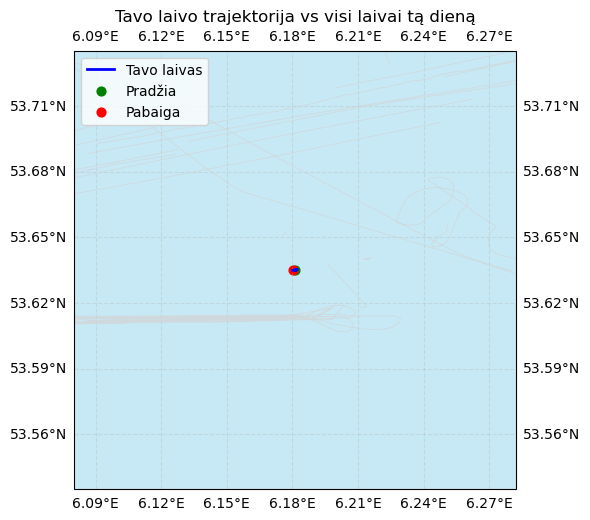

In [42]:
df2["# Timestamp"] = pd.to_datetime(df2["# Timestamp"], dayfirst=True)

# --- parametriai, KURIUOS PASIREGULIUOSI ---
target_mmsi = 311014800              # tavo „įdomus“ laivas
target_day = "2025-05-17"            # kuria diena lygini (yyyy-mm-dd)

# kvadratas – paimkim iš to laivo taškų (plius mažas bufferis),
# kad grafikas būtų kaip tavo paveikslėlyje
day_mask = df2["# Timestamp"].dt.date == pd.to_datetime(target_day).date()
df_day = df2[day_mask].copy()

target = df_day[df_day["MMSI"] == target_mmsi].sort_values("# Timestamp")
lat_min = target["Latitude"].min() - 0.1
lat_max = target["Latitude"].max() + 0.1
lon_min = target["Longitude"].min() - 0.1
lon_max = target["Longitude"].max() + 0.1

# ta pati diena, bet tik taškai kvadrate
box_mask = (
    (df_day["Latitude"]  >= lat_min) &
    (df_day["Latitude"]  <= lat_max) &
    (df_day["Longitude"] >= lon_min) &
    (df_day["Longitude"] <= lon_max)
)
df_box = df_day[box_mask].copy()

# --- funkcija – nedaryti šuolių per sausumą (jei nori – gali praleist) ---
# def split_by_jump(g, max_jump_km=5.0):
#     g = g.sort_values("# Timestamp")
#     if len(g) < 2:
#         return []

#     lat = np.deg2rad(g["Latitude"].values)
#     lon = np.deg2rad(g["Longitude"].values)
#     dlat = np.diff(lat)
#     dlon = np.diff(lon)
#     a = np.sin(dlat/2)**2 + np.cos(lat[:-1]) * np.cos(lat[1:]) * np.sin(dlon/2)**2
#     c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
#     dist_km = 6371 * c

#     break_idx = np.where(dist_km > max_jump_km)[0] + 1
#     return [s for s in np.split(g, break_idx) if len(s) >= 2]

# --- piešimas ---
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=proj)

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)

# fonas
ax.add_feature(cfeature.OCEAN, facecolor="#c7e9f5")
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.coastlines(resolution="10m", linewidth=0.5)
ax.gridlines(draw_labels=True, linestyle="--", alpha=0.3)

# 1) Visų tos dienos laivų trajektorijos (pilkai)
for mmsi, g in df_box.groupby("MMSI"):
    if mmsi == target_mmsi:
        continue
    for seg in split_by_jump(g, max_jump_km=5):
        ax.plot(
            seg["Longitude"].values,
            seg["Latitude"].values,
            color="lightgray",
            linewidth=0.6,
            alpha=0.7,
            transform=proj,
        )

# 2) Tavo laivo trajektorija tame pačiame kvadrate (ryškiai mėlyna)
target_box = df_box[df_box["MMSI"] == target_mmsi]
for seg in split_by_jump(target_box, max_jump_km=5):
    ax.plot(
        seg["Longitude"].values,
        seg["Latitude"].values,
        color="blue",
        linewidth=2,
        transform=proj,
        label="Tavo laivas",
    )

# pradžia/pabaiga to laivo
if not target_box.empty:
    tb = target_box.sort_values("# Timestamp")
    ax.scatter(tb["Longitude"].iloc[0], tb["Latitude"].iloc[0],
               color="green", s=40, transform=proj, label="Pradžia")
    ax.scatter(tb["Longitude"].iloc[-1], tb["Latitude"].iloc[-1],
               color="red", s=40, transform=proj, label="Pabaiga")

ax.set_title("Tavo laivo trajektorija vs visi laivai tą dieną")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("dienos_palyginimas.png", dpi=300)
plt.show()

In [43]:
print(df_day.head())

  # Timestamp Type of mobile       MMSI   Latitude  Longitude  \
0  2025-05-17        Class A  250370000  54.868457   7.389070   
1  2025-05-17        Class A  219750000  55.097437  14.687435   
2  2025-05-17        Class A  219000431  54.651750  11.347600   
3  2025-05-17        Class A  219002823  56.127015  12.309275   
4  2025-05-17   Base Station    2190064  56.716560  11.519063   

      Navigational status   ROT  SOG    COG  Heading  ... Length  \
0  Under way using engine   NaN  4.0  274.5    280.0  ...    NaN   
1  Under way using engine   0.0  0.0  297.6    190.0  ...    NaN   
2  Under way using engine -11.4  7.9   43.6     42.0  ...    NaN   
3      Engaged in fishing   0.0  0.0  101.2    265.0  ...    NaN   
4           Unknown value   NaN  NaN    NaN      NaN  ...    NaN   

  Type of position fixing device Draught Destination  ETA  Data source type  \
0                      Undefined     NaN     Unknown  NaN               AIS   
1                      Undefined     NaN  

In [44]:
import folium
import pandas as pd


df2 = df2.sort_values("# Timestamp")

# Paimam tik lat/lon kaip sąrašą
coords = df2[["Latitude", "Longitude"]].values.tolist()

# Pradinio taško centras žemėlapiui
start_lat = df2["Latitude"].iloc[0]
start_lon = df2["Longitude"].iloc[0]

m = folium.Map(location=[start_lat, start_lon], zoom_start=14)

# Linija – laivo kelionė
folium.PolyLine(
    locations=coords,
    color="blue",
    weight=3,
    opacity=0.8,
).add_to(m)

# Pradžios ir pabaigos markeriai
folium.Marker(
    location=coords[0],
    popup=f"Pradžia: {df2['# Timestamp'].iloc[0]}",
    icon=folium.Icon(color="green")
).add_to(m)

folium.Marker(
    location=coords[-1],
    popup=f"Pabaiga: {df2['# Timestamp'].iloc[-1]}",
    icon=folium.Icon(color="red")
).add_to(m)

m.save("laivo_trajektorija.html")